# Error analysis by setting

This notebook checks where MosBeatNet performs worse than the baseline.

Main outputs:
- overall comparison result
- train → test heatmap
- settings where the baseline is better at both segment and file level


In [9]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)


def find_root():
    candidates = []
    if os.getenv("MOSBEATNET_ROOT"):
        candidates.append(Path(os.environ["MOSBEATNET_ROOT"]).expanduser().resolve())

    cwd = Path.cwd().resolve()
    candidates += [cwd, *cwd.parents]

    for root in dict.fromkeys(candidates):
        stat = root / "output" / "statistical_tests"
        if (stat / "segment_mcnemar.csv").is_file() and (stat / "file_level_permutation.csv").is_file():
            return root

    raise FileNotFoundError("Run inside the project or set MOSBEATNET_ROOT.")


ROOT = find_root()
STAT_DIR = ROOT / "output" / "statistical_tests"
OUT_DIR = ROOT / "data" / "err_analytic"
OUT_DIR.mkdir(parents=True, exist_ok=True)

mcnemar = pd.read_csv(STAT_DIR / "segment_mcnemar.csv")
file_test = pd.read_csv(STAT_DIR / "file_level_permutation.csv")

# filter weighted-sampling experiments
mcnemar = mcnemar[~mcnemar["Experiment"].str.endswith("_ws")].copy()
file_test = file_test[~file_test["Experiment"].str.endswith("_ws")].copy()

print("Segment tests:", len(mcnemar))
print("File tests:", len(file_test))




Segment tests: 216
File tests: 216


## 1. Overall result

In [10]:
def result_table(df):
    out = df["Result"].value_counts().rename_axis("Result").to_frame("Count")
    out["Percent"] = out["Count"] / len(df) * 100
    return out

segment_overall = result_table(mcnemar)
file_overall = result_table(file_test)

print('segment-Level')
display(segment_overall.round(2))
print('File-Level')
display(file_overall.round(2))

segment_overall.to_csv(OUT_DIR / "segment_overall_result.csv")
file_overall.to_csv(OUT_DIR / "file_overall_result.csv")


segment-Level


,Count,Percent
Result,,
MosBeatNet better,145,67.13
Baseline better,54,25.00
No significant difference,17,7.87


File-Level


,Count,Percent
Result,,
MosBeatNet better,142,65.74
Baseline better,51,23.61
No significant difference,23,10.65


## 2. Train → test setting

The heatmap shows the percentage of comparisons where the baseline is significantly better than MosBeatNet.

This is a comparison rate, not the model error rate.


In [11]:
TRAIN_SOURCES = {
    "exp1_indoor": "indoor",
    "exp2_outdoor": "outdoor",
    "exp3_humbug": "humbug",
    "exp4_biodcase": "biodcase",
    "exp5_indoor_outdoor": "indoor+outdoor",
    "exp6_all_sources": "all_sources",
}

def train_source(name):
    name = str(name)
    return next((v for k, v in TRAIN_SOURCES.items() if k in name), "unknown")


file_test["TrainSource"] = file_test["Experiment"].apply(train_source)

total = file_test.groupby(["TrainSource", "Test Set"]).size()
loss = (
    file_test[file_test["Result"] == "Baseline better"]
    .groupby(["TrainSource", "Test Set"])
    .size()
)

rate = (loss / total * 100).fillna(0).unstack(fill_value=0)

display(rate.round(1))

rate.rename_axis("TrainSource").reset_index().to_csv(
    OUT_DIR / "train_test_baseline_better_rate.csv",
    index=False,
)


Test Set,all_domains,biodcase_forest,biodcase_urban,humbug_forest,humbug_urban,indoor_forest,indoor_urban,noise_only,outdoor_gaussian
TrainSource,,,,,,,,,
all_sources,0.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
biodcase,25.0,25.0,0.0,50.0,75.0,50.0,50.0,50.0,25.0
humbug,0.0,25.0,0.0,0.0,0.0,25.0,0.0,0.0,25.0
indoor,0.0,25.0,50.0,25.0,25.0,0.0,0.0,0.0,25.0
indoor+outdoor,0.0,50.0,50.0,0.0,0.0,0.0,0.0,0.0,50.0
outdoor,100.0,100.0,75.0,75.0,50.0,25.0,25.0,75.0,0.0


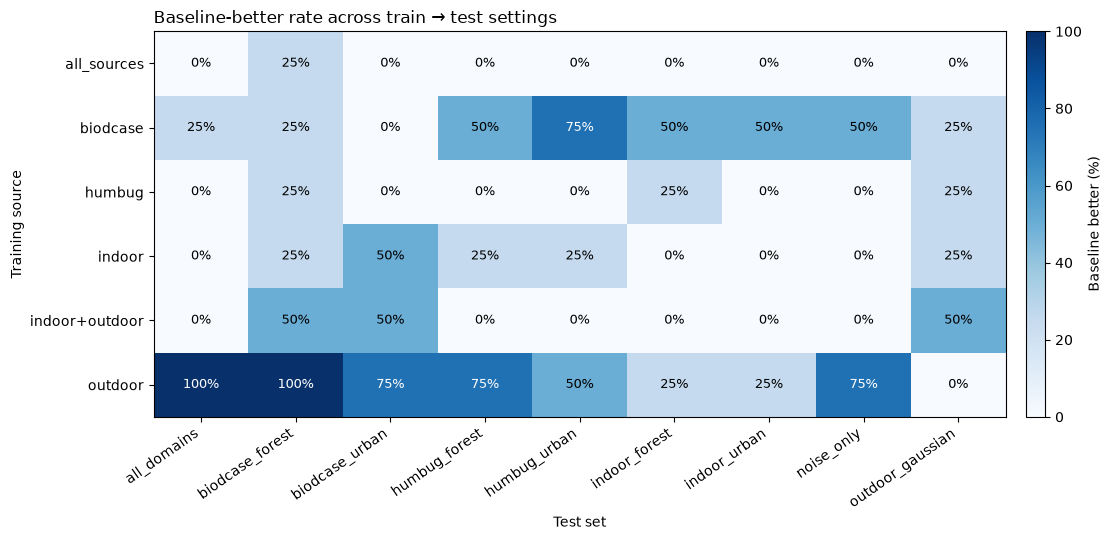

In [12]:
fig, ax = plt.subplots(figsize=(12, 5.5))

im = ax.imshow(rate.values, cmap="Blues", vmin=0, vmax=100, aspect="auto")

ax.set_xticks(range(len(rate.columns)))
ax.set_xticklabels(rate.columns, rotation=35, ha="right")
ax.set_yticks(range(len(rate.index)))
ax.set_yticklabels(rate.index)

ax.set_xlabel("Test set")
ax.set_ylabel("Training source")
ax.set_title("Baseline-better rate across train → test settings", loc="left")

for i in range(rate.shape[0]):
    for j in range(rate.shape[1]):
        value = rate.iloc[i, j]
        ax.text(
            j, i, f"{value:.0f}%",
            ha="center", va="center",
            color="white" if value >= 55 else "black",
            fontsize=9,
        )

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("Baseline better (%)")

plt.tight_layout()
plt.show()


## 3. Strong baseline-better settings

These are cases where both statistical tests give the same result: the baseline is better than MosBeatNet.


In [13]:
keys = ["Experiment", "Seed", "Test Set", "Task", "Baseline"]

compare = file_test.merge(
    mcnemar[keys + ["Result", "pHolm"]],
    on=keys,
    suffixes=("_file", "_segment"),
)

strong = compare[
    (compare["Result_file"] == "Baseline better")
    & (compare["Result_segment"] == "Baseline better")
].copy()

strong["TrainSource"] = strong["Experiment"].apply(train_source)
strong = strong.sort_values("Difference pp")

show = [
    "TrainSource", "Test Set", "Task", "Baseline",
    "Difference pp", "pHolm_file", "pHolm_segment",
]

print("Strong baseline-better cases:", len(strong))
display(strong[show].round(4))


Strong baseline-better cases: 51


,TrainSource,Test Set,Task,Baseline,Difference pp,pHolm_file,pHolm_segment
141,biodcase,outdoor_gaussian,Species,sednet,-24.9089,0.0004,0.0000
126,biodcase,humbug_urban,Species,cfresnet1d_small,-13.0067,0.0004,0.0000
49,outdoor,humbug_forest,Species,sednet,-8.9778,0.0004,0.0000
64,outdoor,noise_only,Noise-only,mosqplus,-6.6750,0.0004,0.0000
122,biodcase,humbug_forest,Species,cfresnet1d_small,-5.5600,0.0004,0.0000
47,outdoor,biodcase_urban,Species,mtrcnn,-4.6483,0.0004,0.0000
124,biodcase,humbug_urban,Species,mosqplus,-4.0644,0.0004,0.0000
43,outdoor,biodcase_forest,Species,mtrcnn,-3.7708,0.0004,0.0000
52,outdoor,humbug_urban,Species,mosqplus,-3.6311,0.0004,0.0000
40,outdoor,biodcase_forest,Species,mosqplus,-3.1875,0.0004,0.0000


keys = ["Experiment", "Seed", "Test Set", "Task", "Baseline"]

compare = file_test.merge(
    mcnemar[keys + ["Result", "pHolm"]],
    on=keys,
    suffixes=("_file", "_segment"),
)

strong = compare[
    (compare["Result_file"] == "Baseline better")
    & (compare["Result_segment"] == "Baseline better")
].copy()

strong["TrainSource"] = strong["Experiment"].apply(train_source)
strong = strong.sort_values("Difference pp")

show = [
    "TrainSource", "Test Set", "Task", "Baseline",
    "Difference pp", "pHolm_file", "pHolm_segment",
]

print("Strong baseline-better cases:", len(strong))
display(strong[show].round(4))

strong.to_csv(
    OUT_DIR / "strong_baseline_better_settings.csv",
    index=False,
)


## Saved files

Tables are saved when they are displayed above.


In [14]:
print("Saved tables to:", OUT_DIR)

for path in sorted(OUT_DIR.glob("*.csv")):
    print(" -", path.name)


Saved tables to: /home/mosbnet/mosdet/mosbeatnet_main/data/err_analytic
 - all_baseline_better_cases.csv
 - baseline_summary.csv
 - class_support_f1.csv
 - confusion_pairs.csv
 - confusion_types.csv
 - error_gap_sex.csv
 - error_gap_simulation_environment.csv
 - error_gap_source_device.csv
 - error_gap_source_environment.csv
 - error_gap_source_name.csv
 - error_gap_species.csv
 - error_gap_subenv.csv
 - factor_conclusion_table.csv
 - file_overall_result.csv
 - hard_recordings_summary.csv
 - metadata_coverage.csv
 - mf1_pairwise_comparison.csv
 - raw_recording_error_gap.csv
 - rms_cache.csv
 - rms_error.csv
 - segment_file_disagreement_cases.csv
 - segment_overall_result.csv
 - snr_error.csv
 - snr_mosbeatnet_vs_baseline.csv
 - statistics_plus_mf1.csv
 - strong_baseline_better_cases.csv
 - task_summary.csv
 - test_set_summary.csv
 - train_test_baseline_better_rate.csv
 - training_source_summary.csv
 - training_source_x_test_set_counts.csv
 - training_source_x_test_set_rates.csv
 - ws_s